In [47]:
pip install scikit-learn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_preprocessed.csv to test_preprocessed (1).csv
Saving train_preprocessed.csv to train_preprocessed (1).csv


In [ ]:
!pip install -q gensim

In [ ]:
import numpy as np
import pandas as pd
import gensim.downloader as api
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("train_preprocessed.csv")
test_df = pd.read_csv("test_preprocessed.csv")

In [ ]:
train_texts = train_df['cleaned'].fillna('').astype(str).tolist()
test_texts = test_df['cleaned'].fillna('').astype(str).tolist()

In [ ]:
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

In [ ]:
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

In [ ]:
max_len = max(max(len(x) for x in train_sequences), max(len(x) for x in test_sequences))
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

In [ ]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_train = train_df['Sentiment'].map(label_map).values
y_test = test_df['Sentiment'].map(label_map).values

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(f"Tokenizationed — Vocab size: {vocab_size}, Max len: {max_len}")

Tokenizationed — Vocab size: 150195, Max len: 80


In [ ]:
fasttext_model = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [55]:
embedding_dim = 300

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in fasttext_model:
        embedding_matrix[i] = fasttext_model[word]

In [67]:
embedding_dim_fast = 100
embedding_matrix_fast = np.zeros((vocab_size, embedding_dim_fast))
for word, i in tokenizer.word_index.items():
    if word in fasttext_model:
        embedding_matrix_fast[i] = fasttext_model[word][:embedding_dim_fast]

In [68]:
class RelativePositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.max_len = max_len
        self.rel_pos_embeddings = self.add_weight(
            name="rel_pos",
            shape=(2 * max_len - 1, embed_dim),
            initializer='random_normal',
            trainable=True
        )

    def call(self, x):
        seq_len = tf.shape(x)[1]
        diag_indices = tf.range(seq_len) - tf.range(seq_len) + self.max_len - 1
        diag_embeddings = tf.gather(self.rel_pos_embeddings, diag_indices)
        return tf.expand_dims(diag_embeddings, 0)


In [69]:
class CausalTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads=2):
        super().__init__()
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.norm = tf.keras.layers.LayerNormalization()
        self.add = tf.keras.layers.Add()

    def call(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.tile(tf.expand_dims(mask, 0), [batch_size, 1, 1])
        attn_output = self.attn(x, x, attention_mask=mask)
        return self.norm(self.add([x, attn_output]))


In [70]:
from sklearn.utils import class_weight

In [72]:
def build_fast_model(vocab_size, embedding_dim, max_len):
    inputs = tf.keras.Input(shape=(max_len,))

    word_emb = tf.keras.layers.Embedding(input_dim=vocab_size,
                                         output_dim=embedding_dim,
                                         weights=[embedding_matrix_fast],
                                         trainable=False)(inputs)

    rel_pos = RelativePositionEmbedding(max_len, embedding_dim)(word_emb)
    x = word_emb + rel_pos

    x = CausalTransformerBlock(embed_dim=embedding_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)
model = build_fast_model(vocab_size, embedding_dim_fast, max_len)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

Class Weights: {0: 1.9637254170706844, 1: 1.9534170515602876, 2: 0.5053464687713439}
Epoch 1/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 856s 108ms/step - accuracy: 0.6164 - loss: 0.8519 - val_accuracy: 0.7819 - val_loss: 0.5599
Epoch 2/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 853s 108ms/step - accuracy: 0.7496 - loss: 0.6703 - val_accuracy: 0.7790 - val_loss: 0.5803
Epoch 3/5
7899/7899 ━━━━━━━━━━━━━━━━━━━━ 856s 107ms/step - accuracy: 0.7624 - loss: 0.6511 - val_accuracy: 0.7854 - val_loss: 0.5751


In [56]:
model = build_fast_model(vocab_size, embedding_dim_fast, max_len)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 80, 100)   │ 15,019,500 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relative_position_… │ (1, 80, 100)      │     15,900 │ embedding_9[0][0] │
│ (RelativePositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 80, 100)   │          0 │ embedding_9[0][0… │
│                     │                   │            │ relative_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_transformer… │ (None, 80, 100)   │     80,900 │ add_13[0][0]      │
│ (CausalTransformer… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ causal_transform… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      6,464 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 3)         │        195 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,122,959 (57.69 MB)

 Trainable params: 103,459 (404.14 KB)

 Non-trainable params: 15,019,500 (57.29 MB)

In [48]:
y_pred = model.predict(X_test).argmax(axis=1)


4232/4232 ━━━━━━━━━━━━━━━━━━━━ 150s 35ms/step


In [49]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.72      0.63     22984
     Neutral       0.64      0.61      0.63     23105
    Positive       0.90      0.85      0.88     89311

    accuracy                           0.79    135400
   macro avg       0.70      0.73      0.71    135400
weighted avg       0.80      0.79      0.79    135400



In [57]:
report_dict = classification_report(y_test, y_pred, target_names=label_map.keys(), output_dict=True)
f1_pos = report_dict['Positive']['f1-score']
f1_neg = report_dict['Negative']['f1-score']
f1_neu = report_dict['Neutral']['f1-score']
print(f"F1 Score (Positive) = {f1_pos:.4f}")
print(f"F1 Score (Negative) = {f1_neg:.4f}")
print(f"F1 Score (Neutral)  = {f1_neu:.4f}")

F1 Score (Positive) = 0.8769
F1 Score (Negative) = 0.6333
F1 Score (Neutral)  = 0.6273


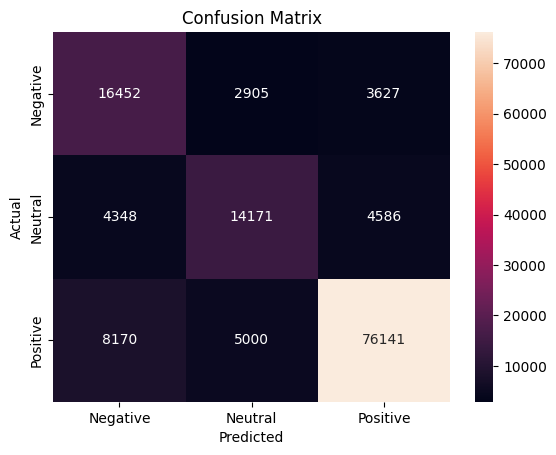

In [54]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [52]:
probs = model.predict(X_test)
auc = roc_auc_score(tf.keras.utils.to_categorical(y_test, 3), probs, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")

4232/4232 ━━━━━━━━━━━━━━━━━━━━ 167s 39ms/step
AUC Score: 0.9013
